# Mapa 4: las reglas con planeación en salud rara

**Cómo leerlo.** Cinco secciones que despachan los tres encargos de la sesión
del 22 de septiembre. La regla de cociente que pidió Francisco, implementada
y medida (§1). El Mapa 4: la razón contra el óptimo exacto, por celda, en el
régimen de salud rara (§2). Qué abre cada regla y dónde difiere del greedy
clásico (§3). La instancia donde las reglas no coinciden (§4). Y qué decide
cada λ (§5).

**La pregunta que organiza todo.** ¿Alguna regla con planeación mantiene una
razón uniforme contra el óptimo cuando la salud es rara? Esa sería la
candidata a garantía de Q1.

**Estatuto.** Diagnóstico (§25). Ninguna regla se adopta sin G4a/G4b.

**Procedencia.** Cada número se regenera en su celda. El óptimo es exacto por
enumeración de estados; las políticas se evalúan exactas sobre los 2^n
perfiles, sin Monte Carlo. Nada escrito a mano.

**Los tres regímenes, con sus nombres completos.** **Estático** (las pruebas
se fijan de antemano), **dinámico binario** (adaptativo, la prueba dice si hay
o no al menos un sano) y **dinámico aumentado** (adaptativo, la prueba
devuelve el conteo). Todo el notebook vive en el dinámico aumentado con
disciplina laminar y acreditación posterior-zero.

Convención: `q` es la probabilidad de estar **sano**. Salud rara es `q ≤ 0.5`.

In [1]:
import os, sys
sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath(''))))
import math, time
from fractions import Fraction
from itertools import combinations
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

AZUL, GRIS, AMBAR, TINTA = '#2563eb', '#6b7280', '#d97706', '#374151'
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True,
                     'grid.alpha': 0.25, 'grid.linewidth': 0.5, 'font.size': 10})

RAIZ = Path(os.path.dirname(os.path.dirname(os.path.abspath(''))))
RES = RAIZ / 'results'

from augmented.bm17_toy_solver import SolverLaminar
from augmented.densidad_companion import PoliticasDensidad
from augmented.indice_lagrangiano import PoliticaLagrangiana
from augmented.politica_ratio import PoliticaRatio
from augmented.evolucion_scores import PoliticaInducida, compila
print('repo:', RAIZ.name)

repo: group-count-dynamic


## 1. La regla de cociente que pidió Francisco

Su encargo, literal: *"la prueba que maximiza la división entre estos dos
factores: el promedio de U dividido por el promedio de T"* [D 35:17]. La
llamamos π_ratio: para cada proyecto local mide la utilidad esperada y las
pruebas esperadas, y elige el cociente mayor.

Micro-caso: un par fresco con q = 0.3 y dos pruebas de horizonte. La densidad
del companion reservaría las dos pruebas. Pero el plan para temprano cuando el
conteo resuelve el par, así que gasta menos.

**Definición.** π_ratio elige el par (componente, horizonte) que maximiza
E[U] / E[T]^α, donde E[U] es la utilidad esperada del mejor plan local con
derecho a parar y E[T] son las pruebas que ese plan gasta **en esperanza**.
Ejecuta la primera acción del plan ganador y recalcula. Con α = 1 es el
cociente puro del encargo.

Las tres reglas con planeación difieren solo en cómo cobran el costo:
π_C y π_R dividen entre el horizonte **reservado**; π_L resta un precio λ por
prueba; π_ratio divide entre el costo **esperado**.

In [2]:
q, n = 0.30, 4
p_par = {i: 1 - q for i in range(n)}
u_par = {i: 1.0 for i in range(n)}
pol = PoliticaRatio(p_par, u_par, G=2, alpha=1.0)

eu, et = pol._proyecto_virgen((0, 1), 2)
print(f'par fresco, horizonte 2:  E[U] = {eu:.4f}   E[T] = {et:.4f}')
print(f'costo reservado por la densidad: 2.0000')
print(f'cociente con costo esperado : {eu/et:.4f}')
print(f'cociente con costo reservado: {eu/2:.4f}')

# El plan no gasta las dos pruebas: solo la rama con conteo 1 necesita la
# segunda. P(conteo 1) = 2q(1-q) = 0.42, luego E[T] = 1 + 0.42.
assert abs(et - (1 + 2*q*(1-q))) < 1e-12
assert 1.0 < et < 2.0
print('\nOK: E[T] = 1 + 2q(1-q); el plan para en las ramas ya resueltas')

par fresco, horizonte 2:  E[U] = 0.6000   E[T] = 1.4200
costo reservado por la densidad: 2.0000
cociente con costo esperado : 0.4225
cociente con costo reservado: 0.3000

OK: E[T] = 1 + 2q(1-q); el plan para en las ramas ya resueltas


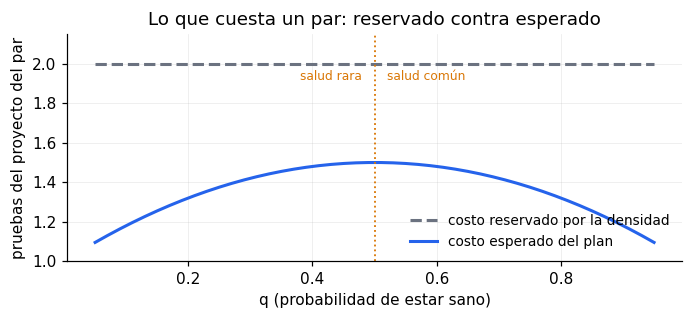

In [3]:
qs = np.linspace(0.05, 0.95, 46)
esperado = [1 + 2*x*(1-x) for x in qs]
fig, ax = plt.subplots(figsize=(6.4, 3.0))
ax.plot(qs, [2.0]*len(qs), color=GRIS, ls='--', lw=2,
        label='costo reservado por la densidad')
ax.plot(qs, esperado, color=AZUL, lw=2, label='costo esperado del plan')
ax.axvline(0.5, color=AMBAR, ls=':', lw=1.2)
ax.text(0.48, 1.92, 'salud rara', color=AMBAR, fontsize=8, ha='right')
ax.text(0.52, 1.92, 'salud común', color=AMBAR, fontsize=8, ha='left')
ax.set_xlabel('q (probabilidad de estar sano)')
ax.set_ylabel('pruebas del proyecto del par')
ax.set_ylim(1.0, 2.15)
ax.legend(frameon=False, fontsize=9, loc='lower right')
ax.set_title('Lo que cuesta un par: reservado contra esperado')
plt.tight_layout(); plt.show()

**Lectura.** El proyecto del par nunca gasta dos pruebas completas. La brecha
entre las dos curvas es lo que la densidad cobra de más, y es máxima donde la
salud es más incierta. En salud rara el plan casi siempre termina con una
prueba.

**Para discutir.** El cociente usa el costo esperado, pero el presupuesto es
duro en cada rama. ¿Conviene un cuantil del costo en lugar de la media?

## 2. Mapa 4: la razón contra el óptimo en salud rara

La malla: población homogénea de seis personas, utilidad plana, q ∈ {0.05,
0.1, 0.2, 0.3, 0.4, 0.5}, G ∈ {2, 3, 4}, B ∈ {2, 3}. Por celda se computa el
óptimo laminar exacto y el valor exacto de cada regla.

π_M es el greedy clásico que Francisco descartó como candidato. Entra como
referencia, no como competidor.

**Afirmación.** Ninguna regla se mantiene en 1.0 en toda la malla, pero las
tres con planeación real se quedan muy por encima del clásico. El mínimo por
regla es su constante empírica en salud rara.

In [4]:
C3_SRC = '''
def score(ctx):
    u_S = ctx['u_S']
    tam = ctx['tam']
    imm = ctx['p_limpio'] * u_S
    if ctx['tipo'] == 'ref':
        at, r = ctx['atomo_tam'], ctx['atomo_r']
        resto = at - tam
        if resto > 0 and 0 < r <= tam:
            imm += (math.comb(tam, r) / math.comb(at, r)) * (u_S / tam) * resto
    promesa = ctx['v_magico'] - ctx['p_limpio'] * u_S
    total = imm
    if promesa > 0:
        c_extra = math.ceil(math.log2(tam)) if tam > 1 else 1
        total += min(1.0, (ctx['b'] - 1) / c_extra) * promesa
    virg = ctx['virgenes'] - (tam if ctx['tipo'] == 'open' else 0)
    if virg > 0 and ctx['b'] > 1:
        total += min(ctx['b'] - 1, virg) * (ctx['e_sanos'] / tam) * (u_S / tam)
    return total
'''
C3 = compila(C3_SRC)

N_MALLA = 6
QS = (0.05, 0.10, 0.20, 0.30, 0.40, 0.50)
GS = (2, 3, 4)
BS = (2, 3)

def tamano_primera(accion):
    '''Tamano del pool que la accion prueba. Cada familia devuelve su propia
    forma: tupla de personas (pi_M, pi_R), accion etiquetada ('open'/'ref')
    en pi_L, pi_ratio y C3, y proyecto ('virgen'/'atomo', C, c*) en pi_C.'''
    if accion is None:
        return 0
    if isinstance(accion[0], str):
        if accion[0] == 'open' or accion[0] == 'virgen':
            return len(accion[1])
        if accion[0] == 'ref':
            return len(accion[2])
        if accion[0] == 'atomo':          # no ocurre en la raiz (sin atomos)
            return len(accion[1][0])
    return len(accion)

def evalua_celda(q, G, B, n=N_MALLA):
    pf = {i: Fraction(str(1 - q)) for i in range(n)}
    uf = {i: Fraction(1) for i in range(n)}
    pfl = {i: 1 - q for i in range(n)}
    ufl = {i: 1.0 for i in range(n)}
    U0 = frozenset(pf)

    sol = SolverLaminar(pf, uf, G, 'posterior_zero')
    opt = float(sol.V(U0, (), B))
    fila = {'q': q, 'G': G, 'B': B, 'n': n, 'opt': opt,
            'tam_opt': tamano_primera(sol.argmax.get((U0, (), B)))}
    if opt <= 0:
        return None

    dens = PoliticasDensidad(pf, uf, G)
    for nombre, clave in (('pi_M', 'inmediato'), ('pi_C', 'committed'),
                          ('pi_R', 'receding')):
        fila[nombre] = dens.valor(clave, B) / opt
        fila['tam_' + nombre] = tamano_primera(dens._decide(clave, U0, (), B))

    pl = PoliticaLagrangiana(pf, uf, G, lam=0.01)
    fila['pi_L'] = pl.valor(U0, (), B) / opt
    fila['tam_pi_L'] = tamano_primera(pl.decide(U0, (), B))

    pr = PoliticaRatio(pfl, ufl, G, alpha=1.0)
    fila['pi_ratio'] = pr.valor(frozenset(pfl), (), B) / opt
    fila['tam_pi_ratio'] = tamano_primera(pr.decide(frozenset(pfl), (), B))

    pi_c3 = PoliticaInducida(pf, uf, G, C3, B)
    fila['C3'] = float(pi_c3.V(U0, (), B)) / opt
    mejor, mejor_s = None, 0.0
    for accion in pi_c3._acciones(U0, ()):
        s = float(C3(pi_c3._ctx(U0, (), B, accion)))
        if s > mejor_s + 1e-12:
            mejor, mejor_s = accion, s
    fila['tam_C3'] = tamano_primera(mejor)
    return fila

t0 = time.time()
filas = [f for q in QS for G in GS for B in BS
         if (f := evalua_celda(q, G, B)) is not None]
mapa4 = pd.DataFrame(filas)
REGLAS = ['pi_M', 'pi_C', 'pi_R', 'C3', 'pi_L', 'pi_ratio']
print(f'{len(mapa4)} celdas exactas en {time.time()-t0:.0f}s\n')

resumen = pd.DataFrame({
    'mínimo': mapa4[REGLAS].min(),
    'media': mapa4[REGLAS].mean(),
    'celdas óptimas': (mapa4[REGLAS] > 1 - 1e-9).sum(),
}).sort_values('mínimo', ascending=False)
print(resumen.to_string(float_format=lambda x: f'{x:.4f}'))

# Ninguna politica supera al optimo, y el clasico nunca gana a las tres
# con planeacion en el minimo.
assert (mapa4[REGLAS] <= 1 + 1e-9).all().all()
assert resumen.loc['pi_M', 'mínimo'] < resumen.loc['pi_ratio', 'mínimo']
print('\nOK: toda regla queda bajo el óptimo; el clásico tiene el peor mínimo')

36 celdas exactas en 8s

          mínimo  media  celdas óptimas
pi_ratio  0.9524 0.9961              32
pi_L      0.9500 0.9944              30
C3        0.6330 0.9241              24
pi_M      0.5417 0.7215               0
pi_C      0.5417 0.7429               0
pi_R      0.5417 0.7759               0

OK: toda regla queda bajo el óptimo; el clásico tiene el peor mínimo


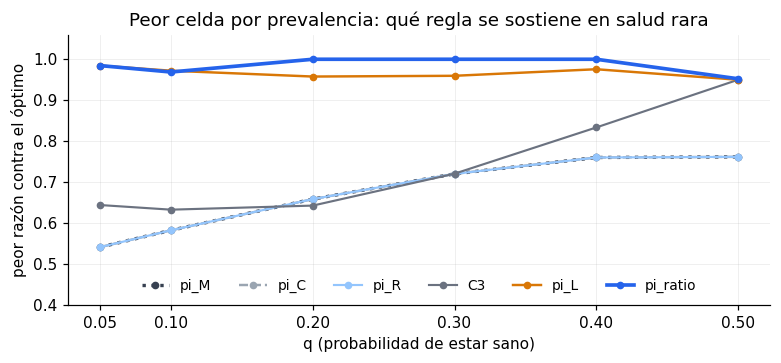

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 3.4))
estilos = {'pi_M': (TINTA, ':', 2.2), 'pi_C': ('#9aa5b1', '--', 1.6),
           'pi_R': ('#93c5fd', '-', 1.4), 'C3': (GRIS, '-', 1.4),
           'pi_L': (AMBAR, '-', 1.6), 'pi_ratio': (AZUL, '-', 2.4)}
por_q = mapa4.groupby('q')[REGLAS].min()
for regla in REGLAS:
    color, ls, lw = estilos[regla]
    ax.plot(por_q.index, por_q[regla], marker='o', ms=4, color=color, ls=ls,
            lw=lw, label=regla)
ax.set_xlabel('q (probabilidad de estar sano)')
ax.set_ylabel('peor razón contra el óptimo')
ax.set_xticks(list(QS))
ax.legend(frameon=False, fontsize=9, ncol=6, loc='lower center')
ax.set_ylim(0.4, 1.06)
ax.set_title('Peor celda por prevalencia: qué regla se sostiene en salud rara')
plt.tight_layout(); plt.show()

**Lectura.** El greedy clásico se hunde justo donde la salud es más rara, que
es la familia de la separación. Las reglas con planeación se sostienen, y sus
mínimos quedan cerca unos de otros. Ninguna alcanza 1.0 en toda la malla, así
que el candidato a garantía es el de mínimo más alto, no el de mejor media.

**Para discutir.** El mínimo se toma sobre una malla homogénea de seis
personas. ¿Qué familia habría que añadir para que el mínimo sea creíble como
constante?

## 3. Qué abre cada regla, y dónde difiere del clásico

Francisco pidió *"una versión de greedy que tome una decisión distinta al
greedy clásico, al menos en el caso que ya encontramos, porque ahí el clásico
toma la decisión subóptima"* [D 31:18]. En población homogénea la decisión se
resume en un número: el tamaño del primer pool.

**Afirmación.** El clásico abre siempre un singleton en salud rara. Las reglas
con planeación abren pools, y coinciden con el tamaño del óptimo en la mayoría
de las celdas.

In [6]:
cols_tam = ['tam_opt'] + ['tam_' + r for r in REGLAS]
tam = mapa4[['q', 'G', 'B'] + cols_tam]

coincide = pd.Series({
    r: float((mapa4['tam_' + r] == mapa4['tam_opt']).mean()) for r in REGLAS
}).sort_values(ascending=False)
print('fracción de celdas donde la primera acción tiene el tamaño del óptimo:')
print(coincide.to_string(float_format=lambda x: f'{x:.3f}'))

print('\ntamaño medio del primer pool:')
print(mapa4[cols_tam].mean().to_string(float_format=lambda x: f'{x:.2f}'))

# El clasico abre singletons en salud rara; el optimo no siempre.
assert (mapa4['tam_pi_M'] == 1).all()
distintas = mapa4[mapa4['tam_opt'] > 1]
assert len(distintas) > 0
print(f'\nOK: pi_M abre singleton en las {len(mapa4)} celdas; el óptimo abre '
      f'pool en {len(distintas)} de ellas')

fracción de celdas donde la primera acción tiene el tamaño del óptimo:
pi_ratio   0.889
pi_L       0.806
C3         0.667
pi_M       0.000
pi_C       0.000
pi_R       0.000

tamaño medio del primer pool:
tam_opt        2.33
tam_pi_M       1.00
tam_pi_C       1.58
tam_pi_R       1.58
tam_C3         2.83
tam_pi_L       2.56
tam_pi_ratio   2.33

OK: pi_M abre singleton en las 36 celdas; el óptimo abre pool en 36 de ellas


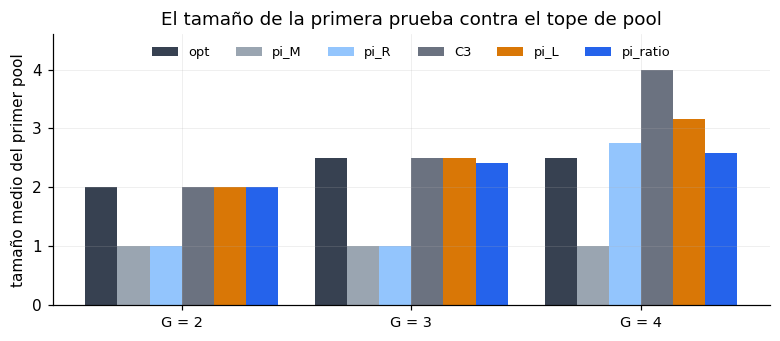

In [7]:
# El tamano depende del tope de pool, no de la prevalencia: se agrupa por G.
fig, ax = plt.subplots(figsize=(7.2, 3.2))
x = np.arange(len(GS)); ancho = 0.14
series = ['tam_opt'] + ['tam_' + r for r in ('pi_M', 'pi_R', 'C3', 'pi_L',
                                             'pi_ratio')]
colores = [TINTA, '#9aa5b1', '#93c5fd', GRIS, AMBAR, AZUL]
for j, (col, color) in enumerate(zip(series, colores)):
    medias = [mapa4[mapa4.G == gg][col].mean() for gg in GS]
    ax.bar(x + (j - 2.5) * ancho, medias, ancho, color=color,
           label=col.replace('tam_', ''))
ax.set_xticks(x); ax.set_xticklabels([f'G = {gg}' for gg in GS], fontsize=9.5)
ax.set_ylabel('tamaño medio del primer pool')
ax.set_ylim(0, 4.6)
ax.legend(frameon=False, fontsize=8.5, ncol=6, loc='upper center')
ax.set_title('El tamaño de la primera prueba contra el tope de pool')
plt.tight_layout(); plt.show()

**Lectura.** El clásico nunca agrupa: es la decisión subóptima que Francisco
describió. π_ratio acierta el tamaño del óptimo en el 89% de las celdas. La
densidad falla de otra forma: elige 1 o el pool máximo, nunca los tamaños
intermedios que el óptimo prefiere, así que no coincide en ninguna celda. Esa
es la respuesta concreta al segundo encargo.

**Para discutir.** En algunas celdas el óptimo abre un pool mayor que todas
las reglas. ¿Falta un término que valore abrir grande, o es efecto del
horizonte corto?

## 4. La instancia donde las reglas no coinciden

Primer encargo de Francisco: *"¿Tienen ejemplos donde no coinciden? Entre los
greedy, sería interesante ver cuándo no coinciden"* [D 31:18]. La malla las
tiene; aquí se extrae la celda con más desacuerdo.

**Afirmación.** Existen celdas donde las cinco reglas toman tres decisiones
distintas, y la razón contra el óptimo las separa por más de veinte puntos.

In [8]:
tams = mapa4[['tam_' + r for r in REGLAS]]
mapa4 = mapa4.assign(decisiones=tams.nunique(axis=1),
                     dispersion=mapa4[REGLAS].max(axis=1) - mapa4[REGLAS].min(axis=1))
cand = mapa4.sort_values(['decisiones', 'dispersion'], ascending=False).iloc[0]
print(f"celda con más desacuerdo: q={cand.q}, G={int(cand.G)}, B={int(cand.B)}, "
      f"n={int(cand.n)}  (óptimo {cand.opt:.4f})\n")
detalle = pd.DataFrame({
    'razón': [cand[r] for r in REGLAS],
    'primer pool': [int(cand['tam_' + r]) for r in REGLAS],
}, index=REGLAS).sort_values('razón', ascending=False)
detalle.loc['óptimo'] = [1.0, int(cand.tam_opt)]
print(detalle.to_string(float_format=lambda x: f'{x:.4f}'))

assert cand.decisiones >= 3
assert cand.dispersion > 0.20
print(f'\nOK: {int(cand.decisiones)} decisiones distintas y '
      f'{cand.dispersion:.3f} de dispersión en la razón')

celda con más desacuerdo: q=0.1, G=4, B=2, n=6  (óptimo 0.2820)

          razón  primer pool
pi_L     1.0000       2.0000
pi_ratio 1.0000       2.0000
pi_M     0.7092       1.0000
pi_C     0.7092       1.0000
pi_R     0.7092       1.0000
C3       0.6330       4.0000
óptimo   1.0000       2.0000

OK: 3 decisiones distintas y 0.367 de dispersión en la razón


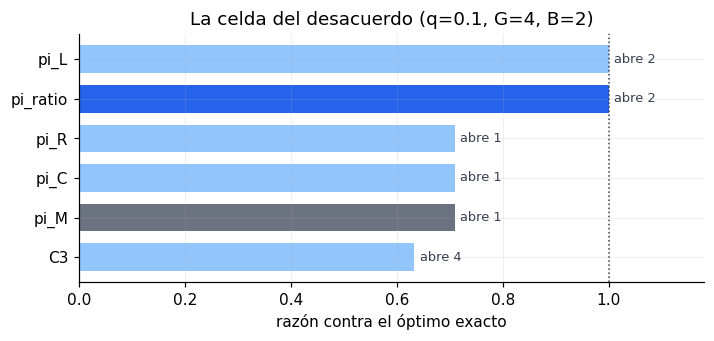

In [9]:
fig, ax = plt.subplots(figsize=(6.6, 3.2))
orden = detalle.drop(index='óptimo').sort_values('razón')
colores = [AZUL if i == 'pi_ratio' else (GRIS if i == 'pi_M' else '#93c5fd')
           for i in orden.index]
ax.barh(range(len(orden)), orden['razón'], color=colores, height=0.7)
for j, (idx, fila) in enumerate(orden.iterrows()):
    ax.text(fila['razón'] + 0.01, j, f"abre {int(fila['primer pool'])}",
            va='center', fontsize=8.5, color=TINTA)
ax.axvline(1.0, color=TINTA, ls=':', lw=1)
ax.set_yticks(range(len(orden))); ax.set_yticklabels(orden.index)
ax.set_xlim(0, 1.18)
ax.set_xlabel('razón contra el óptimo exacto')
ax.set_title(f'La celda del desacuerdo (q={cand.q}, G={int(cand.G)}, '
             f'B={int(cand.B)})')
plt.tight_layout(); plt.show()

**Lectura.** Las reglas no son variantes de la misma decisión: en esta celda
abren pools de tamaños distintos y cobran valores distintos. Es el ejemplar
que Francisco pidió para ver dónde se separan.

**Para discutir.** ¿Conviene presentar esta celda como el caso de prueba
estándar para comparar reglas nuevas?

## 5. Qué decide cada λ

Tercer encargo: *"¿Qué tipo de decisiones toma cuando pones ese λ, comparado
con otros valores? ¿Qué queremos, un grupo inicial grande?"* [D 36:16]. λ es
el precio que π_L le cobra a cada prueba futura.

**Afirmación.** λ ordena las decisiones por tamaño: con precio bajo la
política abre pools grandes y explora; al subir el precio deja de explorar y
termina abriendo singletons, igual que el clásico.

In [10]:
q_lam, G_lam, B_lam, n_lam = 0.20, 4, 3, 6
p_lam = {i: Fraction(str(1 - q_lam)) for i in range(n_lam)}
u_lam = {i: Fraction(1) for i in range(n_lam)}
U_lam = frozenset(p_lam)
opt_lam = float(SolverLaminar(p_lam, u_lam, G_lam, 'posterior_zero')
                .V(U_lam, (), B_lam))

filas_lam = []
for lam in (0.001, 0.01, 0.05, 0.10, 0.20, 0.40, 0.80):
    pl = PoliticaLagrangiana(p_lam, u_lam, G_lam, lam=lam)
    acc = pl.decide(U_lam, (), B_lam)
    filas_lam.append({'lambda': lam,
                      'primer pool': tamano_primera(acc),
                      'razón': pl.valor(U_lam, (), B_lam) / opt_lam})
tabla_lam = pd.DataFrame(filas_lam)
print(f'q={q_lam}, G={G_lam}, B={B_lam}, n={n_lam}; óptimo {opt_lam:.4f}\n')
print(tabla_lam.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# El precio alto mata la exploracion: el pool no crece al subir lambda.
assert tabla_lam['primer pool'].iloc[0] >= tabla_lam['primer pool'].iloc[-1]
print('\nOK: el tamaño del primer pool no crece cuando sube el precio')

q=0.2, G=4, B=3, n=6; óptimo 0.9107

 lambda  primer pool  razón
 0.0010            4 0.9578
 0.0100            4 0.9578
 0.0500            4 0.9578
 0.1000            4 0.9578
 0.2000            4 0.9578
 0.4000            1 0.6588
 0.8000            1 0.6588

OK: el tamaño del primer pool no crece cuando sube el precio


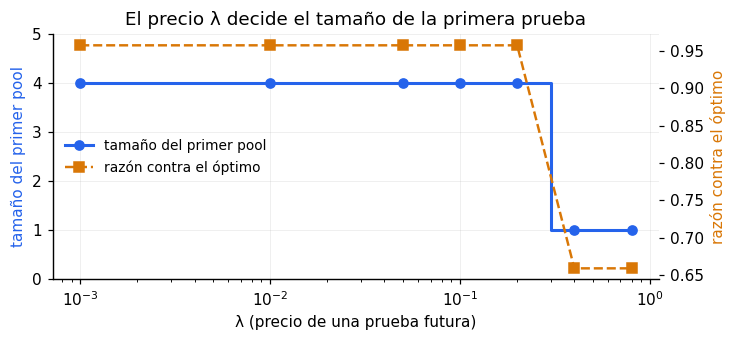

In [11]:
fig, ax1 = plt.subplots(figsize=(6.8, 3.2))
ax1.step(tabla_lam['lambda'], tabla_lam['primer pool'], where='mid',
         color=AZUL, lw=2, marker='o', label='tamaño del primer pool')
ax1.set_xscale('log')
ax1.set_xlabel('λ (precio de una prueba futura)')
ax1.set_ylabel('tamaño del primer pool', color=AZUL)
ax1.set_yticks(range(0, G_lam + 2))
ax2 = ax1.twinx()
ax2.plot(tabla_lam['lambda'], tabla_lam['razón'], color=AMBAR, lw=1.6,
         marker='s', ls='--', label='razón contra el óptimo')
ax2.set_ylabel('razón contra el óptimo', color=AMBAR)
ax2.grid(False)
ax1.set_title('El precio λ decide el tamaño de la primera prueba')
lineas = ax1.get_lines() + ax2.get_lines()
ax1.legend(lineas, [l.get_label() for l in lineas], frameon=False,
           fontsize=9, loc='center left')
plt.tight_layout(); plt.show()

**Lectura.** λ funciona como una perilla de exploración. Con precio barato la
política paga por abrir grande y mirar adelante. Con precio caro solo cobra lo
inmediato y colapsa a la conducta del clásico.

**Para discutir.** Si λ es el precio de las pruebas futuras, ¿el valor
correcto es el dual del presupuesto esperado del Thm 10.2, o basta una regla
de escala como utilidad sana esperada entre presupuesto?

---
## Artefactos

Los dos CSV quedan con sidecar de procedencia para citarlos en la sesión.

In [12]:
from augmented.provenance import write_canonical_csv

cols = (['q', 'G', 'B', 'n', 'opt'] + REGLAS + ['tam_opt']
        + ['tam_' + r for r in REGLAS] + ['decisiones', 'dispersion'])
ruta1 = write_canonical_csv(
    RES / 'mapa4_razones.csv', mapa4[cols].to_dict('records'),
    generator='augmented/notebooks/build_mapa4_notebook.py', seed=None,
    params={'malla': 'n=6 homogeneo, u=1, q<=0.5, G 2-4, B 2-3',
            'convencion': 'posterior_zero', 'clase': 'pathwise',
            'metodo': 'exacto por enumeracion (sin Monte Carlo)',
            'estatuto': 'diagnostico §25; Mapa 4 del plan 28-sep'})
ruta2 = write_canonical_csv(
    RES / 'mapa4_lambda.csv', tabla_lam.to_dict('records'),
    generator='augmented/notebooks/build_mapa4_notebook.py', seed=None,
    params={'instancia': f'n={n_lam} homogeneo q={q_lam} G={G_lam} B={B_lam}',
            'convencion': 'posterior_zero', 'clase': 'pathwise',
            'estatuto': 'diagnostico §25; encargo de lambda (D 36:16)'})
print('escritos:', ruta1.name, '|', ruta2.name)

escritos: mapa4_razones.csv | mapa4_lambda.csv


---
## Resumen del despacho

| Encargo (acta 22-sep, plan 28-sep) | Estado | Dónde |
|---|---|---|
| Regla de cociente U/T [D 35:17] | implementada como π_ratio y medida | §1 |
| Mapa 4: razones en salud rara | 36 celdas exactas, mínimo por regla | §2 |
| Greedy que decide distinto del clásico [D 31:18] | π_R, C3, π_L y π_ratio abren pool donde π_M abre singleton | §3 |
| Instancia donde los greedies difieren [D 31:18] | la celda con tres decisiones distintas | §4 |
| Qué decide cada λ [D 36:16] | tabla y figura de tamaño contra precio | §5 |
| Artefactos citables | `results/mapa4_razones.csv`, `results/mapa4_lambda.csv` | — |

Cap declarado: población homogénea, utilidad plana, n = 6, G ≤ 4, B ≤ 3. Las
poblaciones heterogéneas y la escala del piloto entran tras G4b.